In [20]:
from google.colab import files

files.download("employee_attrition_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
df.to_csv("employee_attrition_cleaned.csv", index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [18]:
from google.colab import files

files.download("employee_attrition_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
import joblib

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": tree_model,
    "Random Forest": forest_model
}

best_model = models[best_model_name]

joblib.dump(best_model, "employee_attrition_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [16]:
from google.colab import files

files.download("employee_attrition_cleaned.csv")
files.download("employee_attrition_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
import joblib

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": tree_model,
    "Random Forest": forest_model
}

joblib.dump(models[best_model_name], "employee_attrition_model.pkl")

print("Best model saved successfully!")

Best model saved successfully!


In [14]:
from sklearn.metrics import roc_auc_score

roc_scores = {
    "Logistic Regression": roc_auc_score(y_test, y_prob_logistic),
    "Decision Tree": roc_auc_score(y_test, y_prob_tree),
    "Random Forest": roc_auc_score(y_test, y_prob_forest)
}

best_model_name = max(roc_scores, key=roc_scores.get)

print("Best Model:", best_model_name)
print("Best ROC-AUC:", round(roc_scores[best_model_name], 4))

Best Model: Logistic Regression
Best ROC-AUC: 0.8035


In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

model_results = []

for name, predictions, probabilities in [
    ("Logistic Regression", y_pred_logistic, y_prob_logistic),
    ("Decision Tree", y_pred_tree, y_prob_tree),
    ("Random Forest", y_pred_forest, y_prob_forest)
]:
    model_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1 Score": f1_score(y_test, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, probabilities)
    })

results = pd.DataFrame(model_results)
display(results)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.887755,0.818182,0.382979,0.521739,0.803515
1,Decision Tree,0.812925,0.394737,0.319149,0.352941,0.662202
2,Random Forest,0.829932,0.363636,0.085106,0.137931,0.781979


In [12]:
from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

forest_model.fit(X_train, y_train)

y_pred_forest = forest_model.predict(X_test)
y_prob_forest = forest_model.predict_proba(X_test)[:, 1]

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [11]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth=6,
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)
y_prob_tree = tree_model.predict_proba(X_test)[:, 1]

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [10]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=2000,
    solver="liblinear",
    random_state=42
)

logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1176, 47)
Testing data: (294, 47)


In [8]:
# Target variable
X = df.drop("Attrition", axis=1)
y = df["Attrition"].map({"Yes": 1, "No": 0})

# Convert categorical columns into numeric columns
X = pd.get_dummies(X, drop_first=True)

print("Features prepared:", X.shape)
print("Target prepared:", y.shape)

Features prepared: (1470, 47)
Target prepared: (1470,)


In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("Dataset loaded!")
print("Shape:", df.shape)

Dataset loaded!
Shape: (1470, 35)


In [4]:
df.to_csv("employee_attrition_cleaned.csv", index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [3]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 1470
Columns: 35


In [2]:
import pandas as pd

from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition (1).csv


In [ ]:
print("==========================================")
print(" EMPLOYEE ATTRITION PREDICTION - RESULT")
print("==========================================")

print(results)

print("\nBest Model:", best_model_name)
print("Best ROC-AUC:", round(roc_scores[best_model_name], 4))

 EMPLOYEE ATTRITION PREDICTION - RESULT
                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.887755   0.818182  0.382979  0.521739  0.803515
1        Decision Tree  0.812925   0.394737  0.319149  0.352941  0.662202
2        Random Forest  0.829932   0.363636  0.085106  0.137931  0.781979

Best Model: Logistic Regression
Best ROC-AUC: 0.8035


In [ ]:
print("==========================================")
print(" EMPLOYEE ATTRITION PREDICTION - RESULT")
print("==========================================")

print(results)

print("\nBest Model:", best_model_name)
print("Best ROC-AUC:", round(roc_scores[best_model_name], 4))

 EMPLOYEE ATTRITION PREDICTION - RESULT
                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.887755   0.818182  0.382979  0.521739  0.803515
1        Decision Tree  0.812925   0.394737  0.319149  0.352941  0.662202
2        Random Forest  0.829932   0.363636  0.085106  0.137931  0.781979

Best Model: Logistic Regression
Best ROC-AUC: 0.8035


In [ ]:
import joblib

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": tree_model,
    "Random Forest": forest_model
}

joblib.dump(
    models[best_model_name],
    "employee_attrition_model.pkl"
)

print("Best model saved successfully!")

Best model saved successfully!


In [ ]:
roc_scores = {
    "Logistic Regression": roc_auc_score(y_test, y_prob_logistic),
    "Decision Tree": roc_auc_score(y_test, y_prob_tree),
    "Random Forest": roc_auc_score(y_test, y_prob_forest)
}

best_model_name = max(roc_scores, key=roc_scores.get)

print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [ ]:
df.to_csv("employee_attrition_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [ ]:
model_results = []

for name, predictions, probabilities in [
    ("Logistic Regression", y_pred_logistic, y_prob_logistic),
    ("Decision Tree", y_pred_tree, y_prob_tree),
    ("Random Forest", y_pred_forest, y_prob_forest)
]:
    model_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions),
        "ROC-AUC": roc_auc_score(y_test, probabilities)
    })

results = pd.DataFrame(model_results)
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.887755,0.818182,0.382979,0.521739,0.803515
1,Decision Tree,0.812925,0.394737,0.319149,0.352941,0.662202
2,Random Forest,0.829932,0.363636,0.085106,0.137931,0.781979


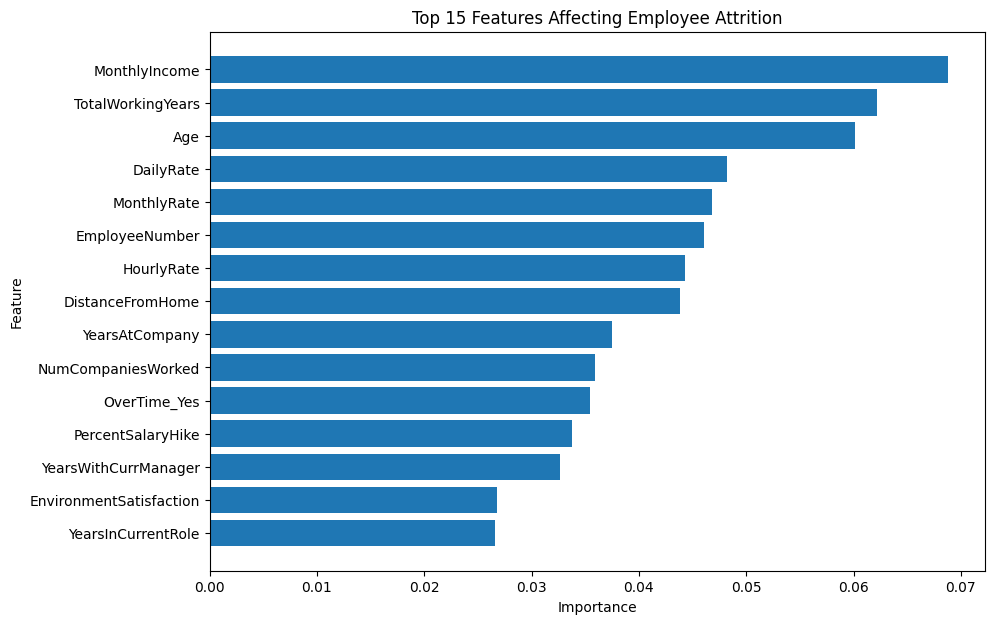

In [ ]:
top_features = feature_importance.head(15).sort_values("Importance")

plt.figure(figsize=(10,7))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features Affecting Employee Attrition")
plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
11,MonthlyIncome,0.068776
19,TotalWorkingYears,0.062180
0,Age,0.060114
1,DailyRate,0.048190
12,MonthlyRate,0.046768
5,EmployeeNumber,0.046062
7,HourlyRate,0.044332
2,DistanceFromHome,0.043818
22,YearsAtCompany,0.037537
13,NumCompaniesWorked,0.035940


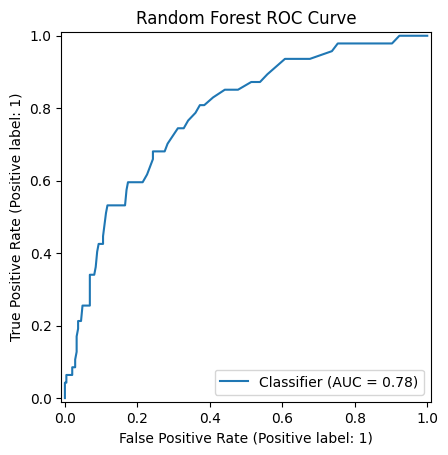

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_forest
)

plt.title("Random Forest ROC Curve")
plt.show()

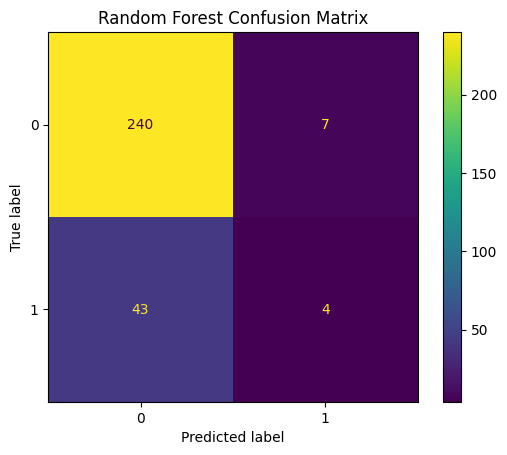

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_forest
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [ ]:
evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_logistic,
    y_prob_logistic
)

evaluate_model(
    "Decision Tree",
    y_test,
    y_pred_tree,
    y_prob_tree
)

evaluate_model(
    "Random Forest",
    y_test,
    y_pred_forest,
    y_prob_forest
)


 Logistic Regression
------------------------------
Accuracy : 0.8878
Precision: 0.8182
Recall   : 0.383
F1 Score : 0.5217
ROC-AUC  : 0.8035

 Decision Tree
------------------------------
Accuracy : 0.8129
Precision: 0.3947
Recall   : 0.3191
F1 Score : 0.3529
ROC-AUC  : 0.6622

 Random Forest
------------------------------
Accuracy : 0.8299
Precision: 0.3636
Recall   : 0.0851
F1 Score : 0.1379
ROC-AUC  : 0.782


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(name, y_test, predictions, probabilities):
    print("\n", name)
    print("-" * 30)
    print("Accuracy :", round(accuracy_score(y_test, predictions), 4))
    print("Precision:", round(precision_score(y_test, predictions), 4))
    print("Recall   :", round(recall_score(y_test, predictions), 4))
    print("F1 Score :", round(f1_score(y_test, predictions), 4))
    print("ROC-AUC  :", round(roc_auc_score(y_test, probabilities), 4))

In [ ]:
from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

forest_model.fit(X_train, y_train)

y_pred_forest = forest_model.predict(X_test)
y_prob_forest = forest_model.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth=6,
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)
y_prob_tree = tree_model.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=2000,
    solver="liblinear",
    random_state=42
)

logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1176, 47)
Testing data: (294, 47)


In [ ]:
X = pd.get_dummies(X, drop_first=True)

print("Features after encoding:", X.shape[1])

Features after encoding: 47


In [ ]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"].map({"Yes": 1, "No": 0})

print("Features:", X.shape)
print("Target:", y.shape)

Features: (1470, 34)
Target: (1470,)


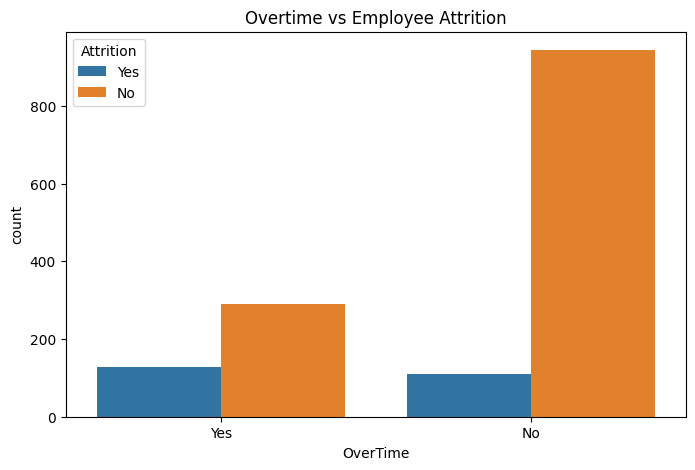

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x="OverTime", hue="Attrition", data=df)
plt.title("Overtime vs Employee Attrition")
plt.show()

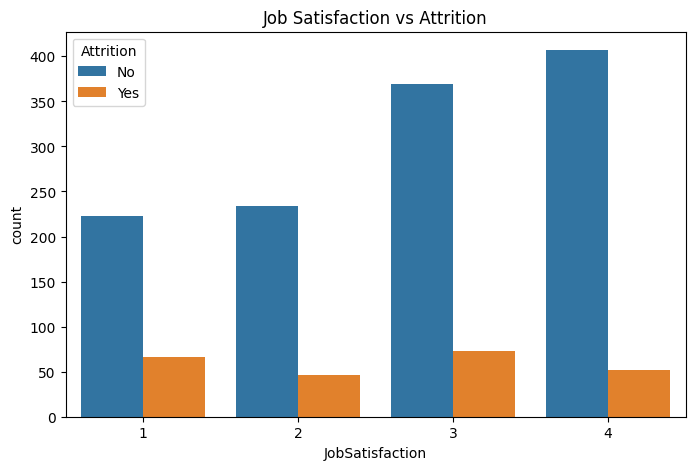

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x="JobSatisfaction", hue="Attrition", data=df)
plt.title("Job Satisfaction vs Attrition")
plt.show()

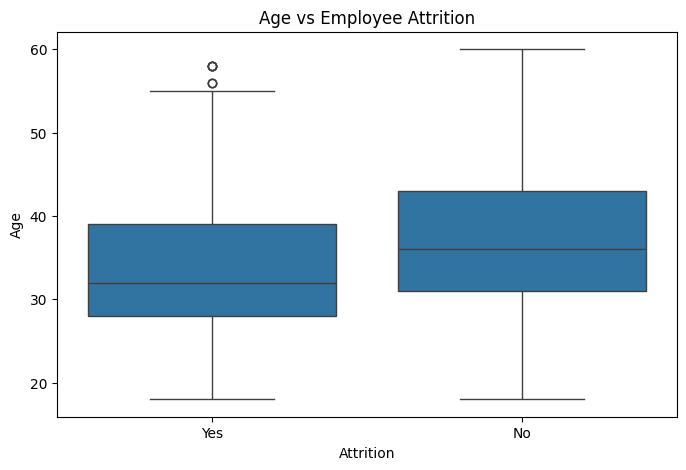

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Attrition", y="Age", data=df)
plt.title("Age vs Employee Attrition")
plt.show()

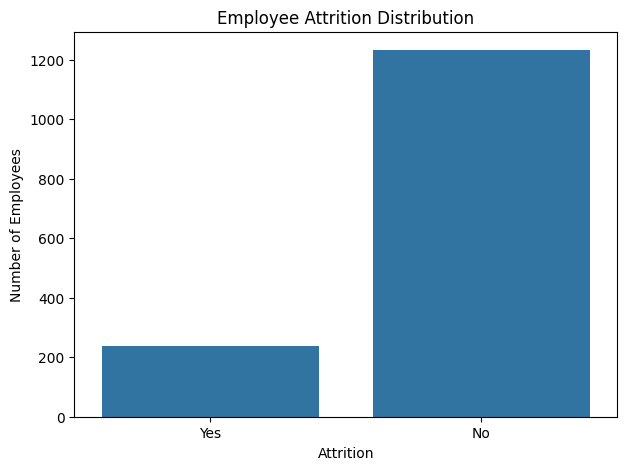

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(x="Attrition", data=df)
plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()

In [ ]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [ ]:
df["Attrition"].value_counts()

,count
Attrition,
No,1233
Yes,237


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 1470
Columns: 35


In [ ]:
print(uploaded.keys())

dict_keys(['WA_Fn-UseC_-HR-Employee-Attrition (1).csv'])


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!
